## **Setup and Imports**

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_palette("husl")

# Add path to access modules
code_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/code'
sys.path.insert(0, code_path)
sys.path.insert(0, os.path.join(code_path, 'Script'))
sys.path.insert(0, os.path.join(code_path, 'modules'))

# Import the Gradient Boosting Classification class
from Classification_Gradient_Boosting_Algo import GradientBoostingClassification

print(" \u2611 Setup complete!")

 ☑ Setup complete!


## **Initialize Trainer (Loads Data)**

In [2]:
# Path to your CSV file
file_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/archive/car_prices.csv'

# Create trainer instance (automatically loads and preprocesses data for classification)
trainer = GradientBoostingClassification(file_path)

print("\n \u2611 Trainer initialized! Data is ready for gradient boosting classification.")

GRADIENT BOOSTING CLASSIFICATION MODELS

Ὄ2 Loading preprocessed data...
✅ Loaded 558,837 rows and 16 columns

STEP 1: CLEANING DATA
✅ Dropped columns: ['vin']
✅ Cleaned transmission column - fixed invalid values
⚠️ Dropped saledate (could not parse)

STEP 2: HANDLING MISSING VALUES
⚠️ Missing values found: {'make': np.int64(10301), 'model': np.int64(10399), 'trim': np.int64(10651), 'body': np.int64(13195), 'condition': np.int64(11820), 'odometer': np.int64(94), 'color': np.int64(749), 'interior': np.int64(749), 'mmr': np.int64(38), 'sellingprice': np.int64(12)}
✅ Filled transmission missing values with 'automatic'
✅ Filled make missing values with mode: 'Ford'
✅ Filled model missing values with mode: 'Altima'
✅ Filled trim missing values with mode: 'Base'
✅ Filled body missing values with mode: 'Sedan'
✅ Filled color missing values with mode: 'black'
✅ Filled interior missing values with mode: 'black'
✅ Filled condition missing values with median: 35.00
✅ Filled odometer missing value

2026-05-02 11:39:18,244 - tornado.application - ERROR - Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7e9fdf297550>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 268-269: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(

✅ Scaled 11 numeric features

PREPARING CLASSIFICATION DATA


Exception in callback BaseAsyncIOLoop._handle_events(29, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(29, 1)>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 123-124: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 601, in _handle_events
    self._handle_recv()
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/z

## **Train XGBoost Classifier**

In [3]:
# Train XGBoost Classifier
model_xgb, metrics_xgb = trainer.train_xgboost(n_estimators=200, learning_rate=0.05)
print("\n \u2611 XGBoost Classifier training complete!")


[TRAIN] XGBoost Classifier (n_estimators=200, lr=0.05)

   [RESULTS]
   Training Accuracy: 0.9318
   Test Accuracy: 0.9291
   Test Precision: 0.9294
   Test Recall: 0.9291
   Test F1-Score: 0.9292
   Training time: 18.31 seconds

   Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  35476  2249    25
            Med  1921  33094  1803
            High    5  1920  35275
   [SAVE] Model saved: xgboost_classifier.pkl
   [FILE] Classification report saved: xgboost_classification_report.csv
   [FILE] Predictions saved: xgboost_predictions.csv

   [TOP] Top 10 Features (XGBoost):
      mmr: 0.9004
      condition: 0.0352
      seller_encoded: 0.0103
      year: 0.0090
      transmission_manual: 0.0078
      state_encoded: 0.0067
      odometer: 0.0046
      make_encoded: 0.0040
      model_encoded: 0.0038
      trim_encoded: 0.0034
   [FILE] Feature importance saved: xgboost_feature_importance.csv

 ☑ XGBoost Classifier training complete!


## **Train LightGBM Classifier**

In [4]:
# Train LightGBM Classifier
model_lgb, metrics_lgb = trainer.train_lightgbm(n_estimators=200, learning_rate=0.05)
print("\n \u2611 LightGBM Classifier training complete!")


[TRAIN] LightGBM Classifier (n_estimators=200, lr=0.05)

   [RESULTS]
   Training Accuracy: 0.9328
   Test Accuracy: 0.9300
   Test Precision: 0.9302
   Test Recall: 0.9300
   Test F1-Score: 0.9301
   Training time: 14.64 seconds

   Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  35532  2193    25
            Med  1911  33127  1780
            High    6  1907  35287
   [SAVE] Model saved: lightgbm_classifier.pkl
   [FILE] Classification report saved: lightgbm_classification_report.csv
   [FILE] Predictions saved: lightgbm_predictions.csv

   [TOP] Top 10 Features (LightGBM):
      mmr: 3597.0000
      condition: 3390.0000
      seller_encoded: 2328.0000
      odometer: 2088.0000
      year: 1342.0000
      state_encoded: 1292.0000
      model_encoded: 1159.0000
      trim_encoded: 823.0000
      make_encoded: 779.0000
      body_encoded: 658.0000
   [FILE] Feature importance saved: lightgbm_feature_importance.csv

 ☑ LightGBM Classifier 

## **Train CatBoost Classifier**

In [5]:
#  Train CatBoost Classifier
model_cb, metrics_cb = trainer.train_catboost(iterations=200, learning_rate=0.05)
print("\n \u2611 CatBoost Classifier training complete!")


[TRAIN] CatBoost Classifier (iterations=200, lr=0.05)

   [RESULTS]
   Training Accuracy: 0.9283
   Test Accuracy: 0.9269
   Test Precision: 0.9271
   Test Recall: 0.9269
   Test F1-Score: 0.9270
   Training time: 24.12 seconds

   Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  35372  2352    26
            Med  1967  32919  1932
            High    4  1888  35308
   [SAVE] Model saved: catboost_classifier.pkl
   [FILE] Classification report saved: catboost_classification_report.csv
   [FILE] Predictions saved: catboost_predictions.csv

   [TOP] Top 10 Features (CatBoost):
      mmr: 67.5367
      condition: 15.7682
      seller_encoded: 4.5809
      year: 3.1107
      odometer: 3.0151
      model_encoded: 1.9515
      state_encoded: 1.2171
      make_encoded: 0.8874
      trim_encoded: 0.8275
      body_encoded: 0.5341
   [FILE] Feature importance saved: catboost_feature_importance.csv

 ☑ CatBoost Classifier training complete!


## **Train AdaBoost Classifier**

In [6]:
#  Train AdaBoost Classifier
model_ada, metrics_ada = trainer.train_adaboost(n_estimators=200, learning_rate=0.05)
print("\n \u2611 AdaBoost Classifier training complete!")


[TRAIN] AdaBoost Classifier (n_estimators=200, lr=0.05)

   [RESULTS]
   Training Accuracy: 0.9141
   Test Accuracy: 0.9132
   Test Precision: 0.9130
   Test Recall: 0.9132
   Test F1-Score: 0.9131
   Training time: 106.03 seconds

   Confusion Matrix:
                 Predicted
                 Low  Med  High
      Actual Low  35145  2513    92
            Med  2695  31772  2351
            High    5  2042  35153
   [SAVE] Model saved: adaboost_classifier.pkl
   [FILE] Classification report saved: adaboost_classification_report.csv
   [FILE] Predictions saved: adaboost_predictions.csv

   [TOP] Top 10 Features (AdaBoost):
      mmr: 0.9225
      seller_encoded: 0.0535
      condition: 0.0240
      year: 0.0000
      make_encoded: 0.0000
      model_encoded: 0.0000
      trim_encoded: 0.0000
      body_encoded: 0.0000
      transmission_manual: 0.0000
      state_encoded: 0.0000
   [FILE] Feature importance saved: adaboost_feature_importance.csv

 ☑ AdaBoost Classifier training comple

## **Compare All Models**

In [7]:
#  Compare all gradient boosting classification models
results_df = trainer.save_all_results()

print("\n" + "="*60)
print(" GRADIENT BOOSTING CLASSIFICATION COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy']
best_f1 = results_df.iloc[0]['Test F1-Score']

print(f"\n BEST GRADIENT BOOSTING MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f}")
print(f"   Test F1-Score: {best_f1:.4f}")


[RESULTS] GRADIENT BOOSTING CLASSIFICATION COMPARISON
              Model  Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Training Time (s)
   LightGBM (n=200)        0.932814       0.930016        0.930234     0.930016       0.930110          14.639249
    XGBoost (n=200)        0.931758       0.929112        0.929354     0.929112       0.929215          18.305286
CatBoost (iter=200)        0.928306       0.926911        0.927098     0.926911       0.926989          24.123502
   AdaBoost (n=200)        0.914123       0.913231        0.912971     0.913231       0.913079         106.033246

[SAVE] Results saved to:
   CSV: /kaggle/working/results/gradient_boosting_classification_comparison.csv
   JSON: /kaggle/working/results/gradient_boosting_classification_comparison.json

[WINNER] BEST GRADIENT BOOSTING MODEL: LightGBM (n=200)
   Test Accuracy: 0.9300
   Test F1-Score: 0.9301

 GRADIENT BOOSTING CLASSIFICATION COMPARISON
              Model  Train Accurac

## **Plot Confusion Matrix for Best Model**

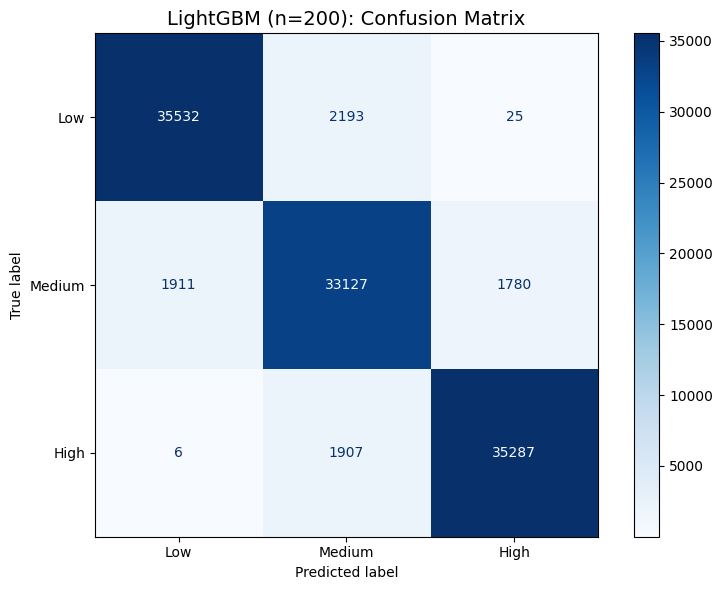

 Confusion matrix saved to: /kaggle/working/results/gb_cm_best_model.png


In [8]:
#  Plot confusion matrix for the best model
from sklearn.metrics import ConfusionMatrixDisplay

# Map model names to model objects
models_map = {
    'XGBoost (n=200)': model_xgb,
    'LightGBM (n=200)': model_lgb,
    'CatBoost (iter=200)': model_cb,
    'AdaBoost (n=200)': model_ada
}

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = models_map[best_model_name]

# Get predictions
y_pred_best = best_model.predict(trainer.X_test)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    trainer.y_test, y_pred_best,
    display_labels=trainer.class_names,
    ax=ax,
    cmap='Blues'
)
ax.set_title(f'{best_model_name}: Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/results/gb_cm_best_model.png', dpi=150)
plt.show()
print(" Confusion matrix saved to: /kaggle/working/results/gb_cm_best_model.png")

## **Plot Model Comparison Bar Chart**

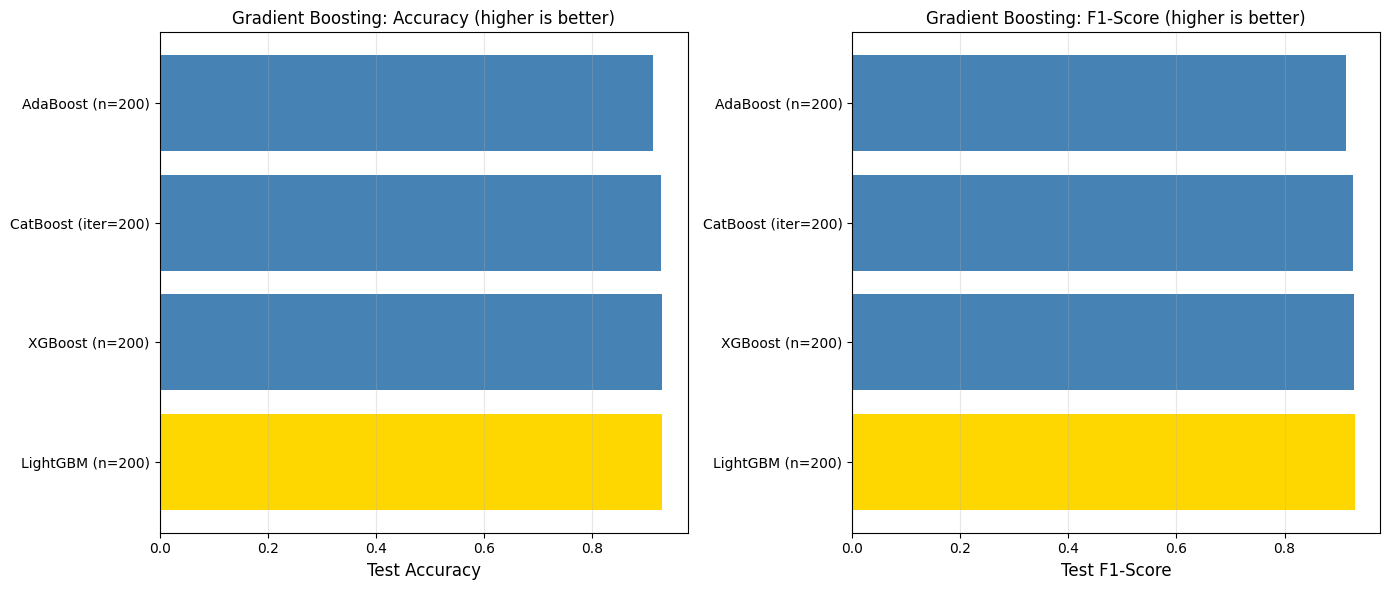

 Comparison chart saved!


In [9]:
# Visual comparison of all gradient boosting models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
axes[0].barh(results_df['Model'], results_df['Test Accuracy'], color=colors)
axes[0].set_xlabel('Test Accuracy', fontsize=12)
axes[0].set_title('Gradient Boosting: Accuracy (higher is better)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: F1-Score
axes[1].barh(results_df['Model'], results_df['Test F1-Score'], color=colors)
axes[1].set_xlabel('Test F1-Score', fontsize=12)
axes[1].set_title('Gradient Boosting: F1-Score (higher is better)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/kaggle/working/results/gb_model_comparison.png', dpi=150)
plt.show()
print(" Comparison chart saved!")

## **Feature Importance for Best Model**

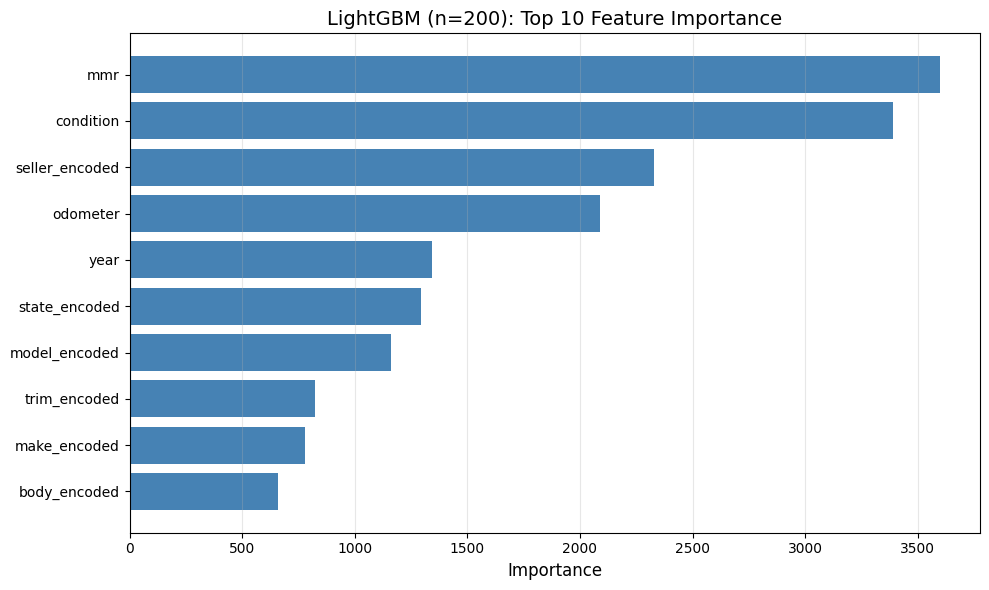

 Feature importance plot saved!

 Top 10 Features (LightGBM (n=200)):
   mmr: 3597.0000
   condition: 3390.0000
   seller_encoded: 2328.0000
   odometer: 2088.0000
   year: 1342.0000
   state_encoded: 1292.0000
   model_encoded: 1159.0000
   trim_encoded: 823.0000
   make_encoded: 779.0000
   body_encoded: 658.0000


In [10]:
#  Feature importance for the best model
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'get_feature_importance'):
    importances = best_model.get_feature_importance()
else:
    importances = None

if importances is not None:
    feature_names = trainer.X_train.columns
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'{best_model_name}: Top 10 Feature Importance', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('/kaggle/working/results/gb_feature_importance_best_model.png', dpi=150)
    plt.show()
    print(" Feature importance plot saved!")
    
    print(f"\n Top 10 Features ({best_model_name}):")
    for idx, row in importance_df.iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")
else:
    print(f"Best model ({best_model_name}) has no feature importance available.")

## **Classification Report for Best Model**

In [ ]:
#  Display detailed classification report for best model
from sklearn.metrics import classification_report

print("="*60)
print(f" CLASSIFICATION REPORT - {best_model_name}")
print("="*60)

report = classification_report(trainer.y_test, y_pred_best, target_names=trainer.class_names)
print(report)

# Also show per-class metrics in a table
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    trainer.y_test, y_pred_best, average=None, labels=[0, 1, 2]
)

report_df = pd.DataFrame({
    'Class': ['Low (0)', 'Medium (1)', 'High (2)'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print("\n Per-Class Metrics:")
print(report_df.to_string(index=False))